# 本次模擬cmd log資訊

* 2026/05/28（12點）開始模擬
* 只保留最後一個iteration(3790)的迭代資訊和AMReX finalize(如下)loss


total run: 1781s

# 使用者設定

In [1]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================
PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

# FE layer range, unit: nm
FE_Z_LO_NM = 21.5
FE_Z_HI_NM = 29.5

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = -16.0
FE_X_HI_NM = 16.0

FE_Y_LO_NM = -16.0
FE_Y_HI_NM = 16.0

ALPHA = -2.5e10
BETA = 6.0e10
SMALL_GAMMA = 1.5e11
G11 = 1.0e-9
G44 = 1.0e-9


# 3D sweep plot要畫的電壓欄位：-5, -4, ..., 5
VOLTAGES = np.arange(-5, 6, 1)
# 3D contour 要畫的plotfile
PLOTFILE_NAME = "plt00000107"

## Utils

In [3]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

# plot

## 看有哪些 plotfile

In [4]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)


Available plotfiles:
   plt00000000
   plt00000024
   plt00000033
   plt00000042
   plt00000051
   plt00000059
   plt00000067
   plt00000075
   plt00000083
   plt00000091
   plt00000099
   plt00000107
   plt00000115
   plt00000123
   plt00000131
   plt00000139
   plt00000147
   plt00000155
   plt00000164
   plt00000173
   plt00000182
   plt00000191


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [5]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-05-28 13:12:00,467 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 13:12:00,468 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:00,468 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:00,470 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_within_domain',
 '_load_requirements',
 '_localize_check',
 '_lookup_c

### 用key word查看dir(ds)中可能會用到的attribute

In [6]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [7]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [8]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [9]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [10]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotations__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__format__
__ge__
__getattribute__
__getitem__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_state
_fill_child_mask
_finalize_parallel
_first_match

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [11]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.95e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.475e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.95e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [12]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-05-28 13:12:00,834 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-28 13:12:00,835 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:00,836 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:00,836 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


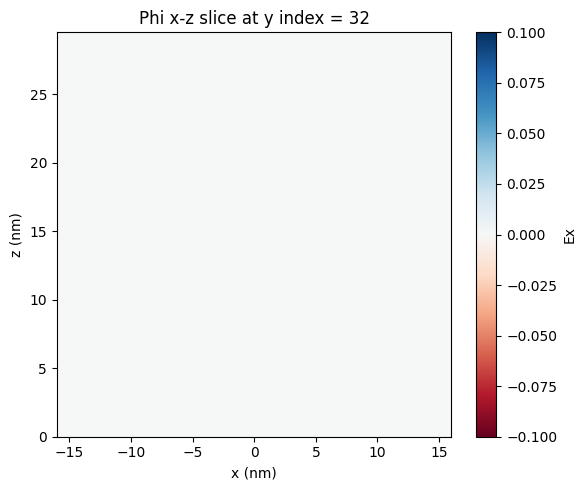

yt : [INFO     ] 2026-05-28 13:12:01,138 Parameters: current_time              = 4.8e-12
yt : [INFO     ] 2026-05-28 13:12:01,139 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:01,139 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:01,140 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


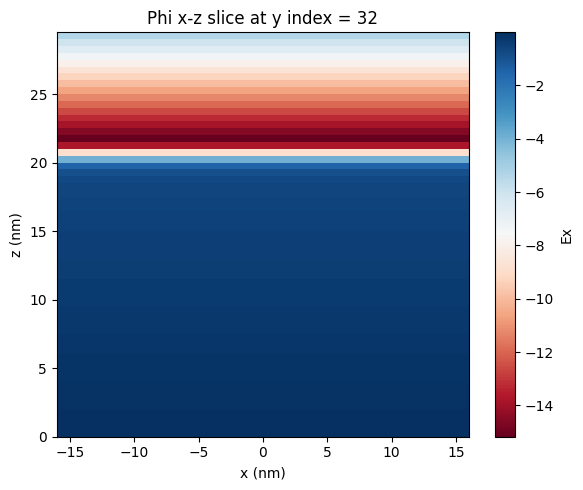

yt : [INFO     ] 2026-05-28 13:12:01,387 Parameters: current_time              = 6.599999999999999e-12
yt : [INFO     ] 2026-05-28 13:12:01,387 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:01,387 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:01,388 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


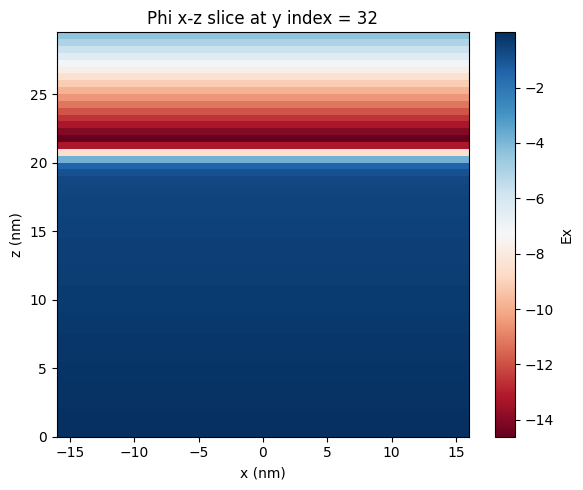

yt : [INFO     ] 2026-05-28 13:12:01,624 Parameters: current_time              = 8.4e-12
yt : [INFO     ] 2026-05-28 13:12:01,625 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:01,625 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:01,625 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


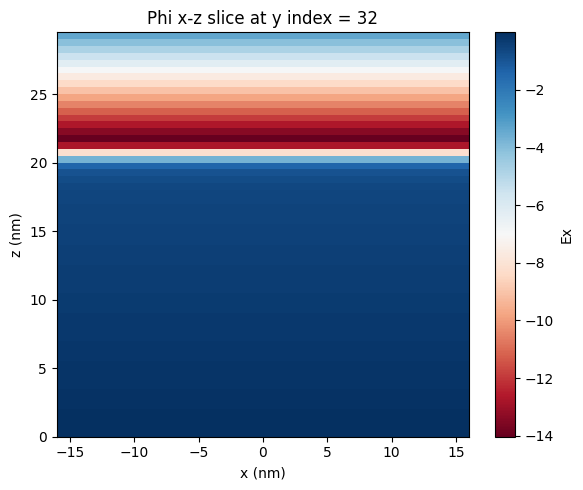

yt : [INFO     ] 2026-05-28 13:12:01,988 Parameters: current_time              = 1.02e-11
yt : [INFO     ] 2026-05-28 13:12:01,989 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:01,989 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:01,990 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


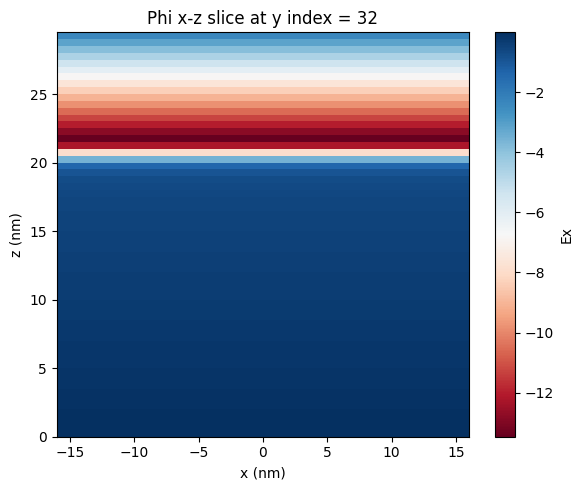

yt : [INFO     ] 2026-05-28 13:12:02,216 Parameters: current_time              = 1.1799999999999999e-11
yt : [INFO     ] 2026-05-28 13:12:02,217 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:02,217 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:02,218 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


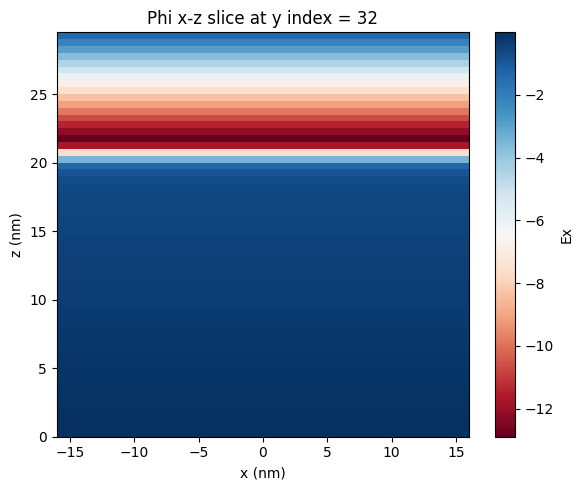

yt : [INFO     ] 2026-05-28 13:12:02,451 Parameters: current_time              = 1.3399999999999999e-11
yt : [INFO     ] 2026-05-28 13:12:02,452 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:02,453 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:02,453 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


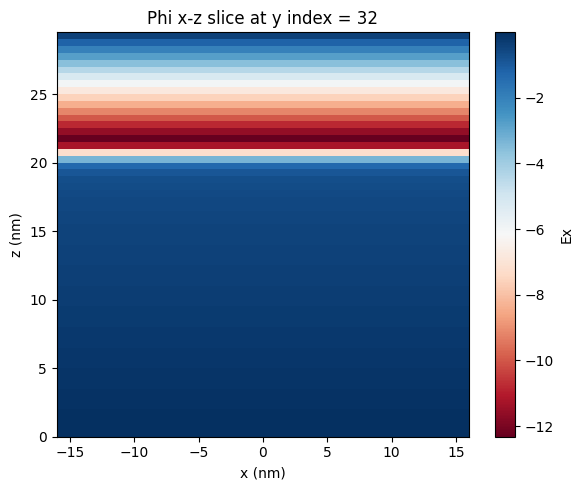

yt : [INFO     ] 2026-05-28 13:12:02,682 Parameters: current_time              = 1.5e-11
yt : [INFO     ] 2026-05-28 13:12:02,683 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:02,684 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:02,684 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


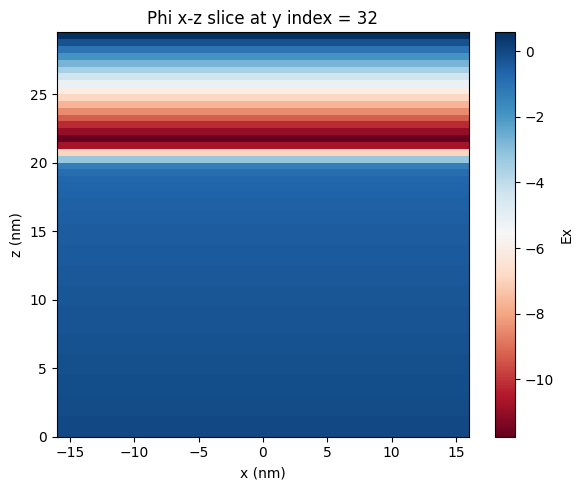

yt : [INFO     ] 2026-05-28 13:12:02,916 Parameters: current_time              = 1.66e-11
yt : [INFO     ] 2026-05-28 13:12:02,916 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:02,917 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:02,917 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


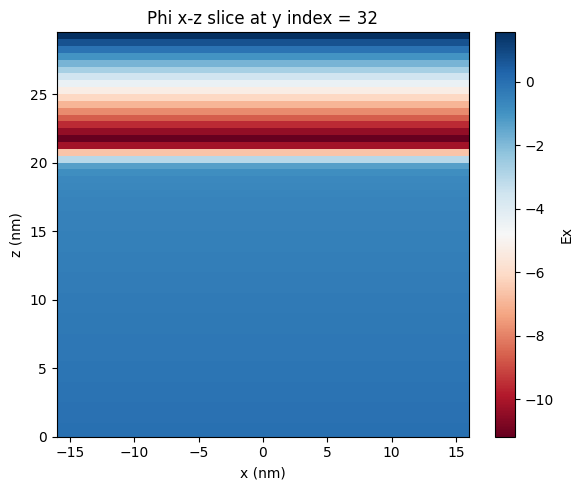

yt : [INFO     ] 2026-05-28 13:12:03,148 Parameters: current_time              = 1.82e-11
yt : [INFO     ] 2026-05-28 13:12:03,149 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:03,150 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:03,150 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


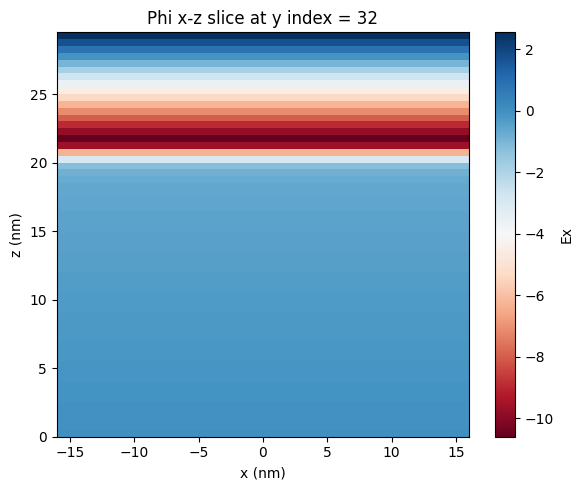

yt : [INFO     ] 2026-05-28 13:12:03,500 Parameters: current_time              = 1.98e-11
yt : [INFO     ] 2026-05-28 13:12:03,501 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:03,502 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:03,502 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


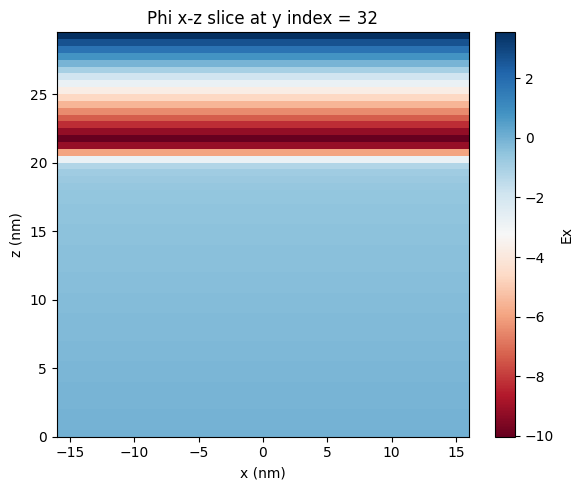

yt : [INFO     ] 2026-05-28 13:12:03,716 Parameters: current_time              = 2.14e-11
yt : [INFO     ] 2026-05-28 13:12:03,717 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:03,717 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:03,718 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


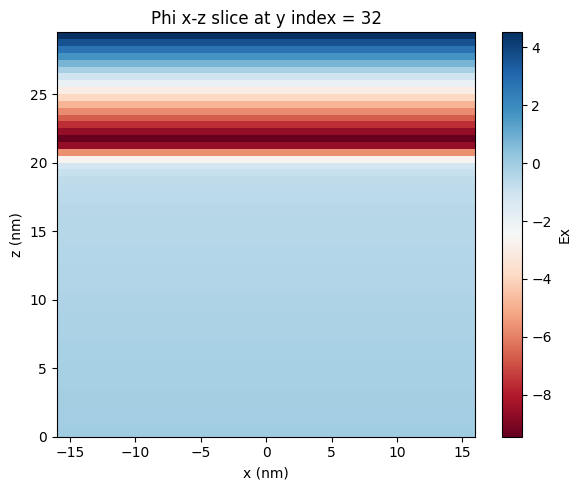

yt : [INFO     ] 2026-05-28 13:12:03,943 Parameters: current_time              = 2.2999999999999998e-11
yt : [INFO     ] 2026-05-28 13:12:03,944 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:03,945 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:03,945 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


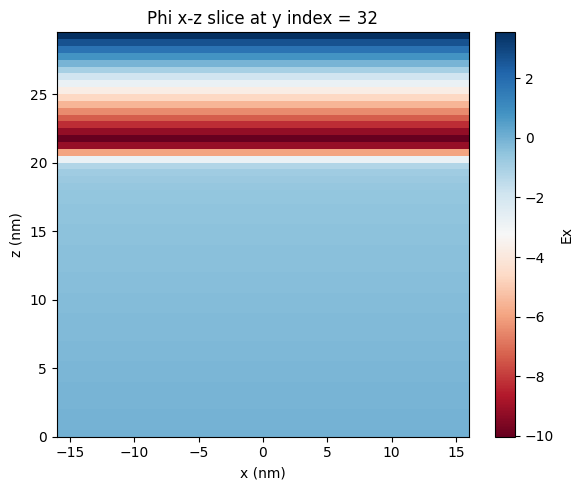

yt : [INFO     ] 2026-05-28 13:12:04,170 Parameters: current_time              = 2.4599999999999998e-11
yt : [INFO     ] 2026-05-28 13:12:04,171 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:04,171 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:04,171 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


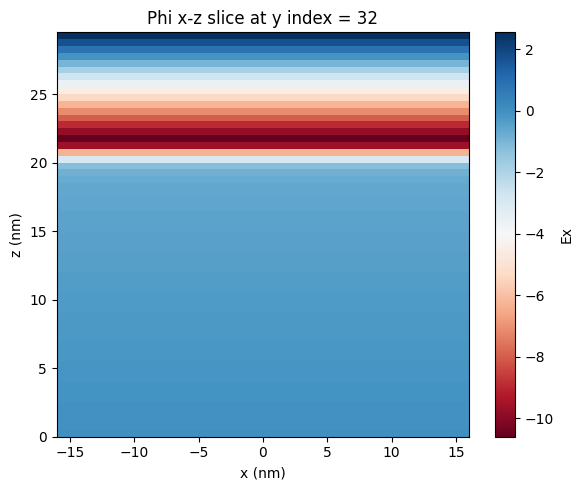

yt : [INFO     ] 2026-05-28 13:12:04,384 Parameters: current_time              = 2.6199999999999997e-11
yt : [INFO     ] 2026-05-28 13:12:04,385 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:04,386 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:04,386 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


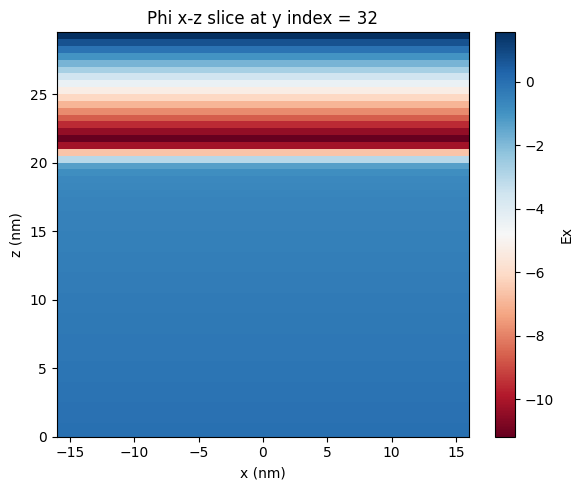

yt : [INFO     ] 2026-05-28 13:12:04,738 Parameters: current_time              = 2.7799999999999997e-11
yt : [INFO     ] 2026-05-28 13:12:04,739 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:04,739 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:04,740 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


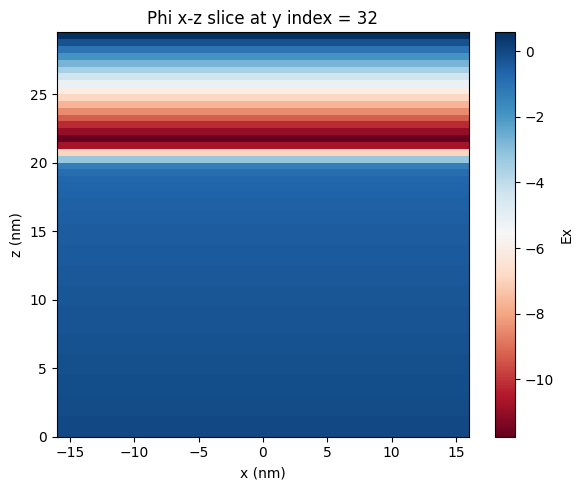

yt : [INFO     ] 2026-05-28 13:12:04,952 Parameters: current_time              = 2.94e-11
yt : [INFO     ] 2026-05-28 13:12:04,952 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:04,953 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:04,953 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


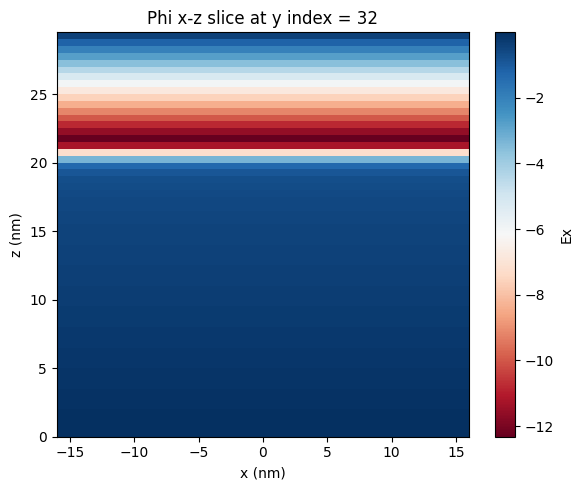

yt : [INFO     ] 2026-05-28 13:12:05,169 Parameters: current_time              = 3.100000000000003e-11
yt : [INFO     ] 2026-05-28 13:12:05,169 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:05,170 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:05,170 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


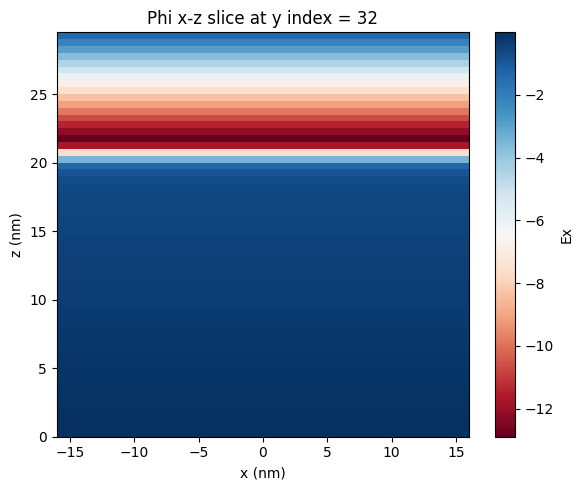

yt : [INFO     ] 2026-05-28 13:12:05,388 Parameters: current_time              = 3.280000000000006e-11
yt : [INFO     ] 2026-05-28 13:12:05,389 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:05,390 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:05,391 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


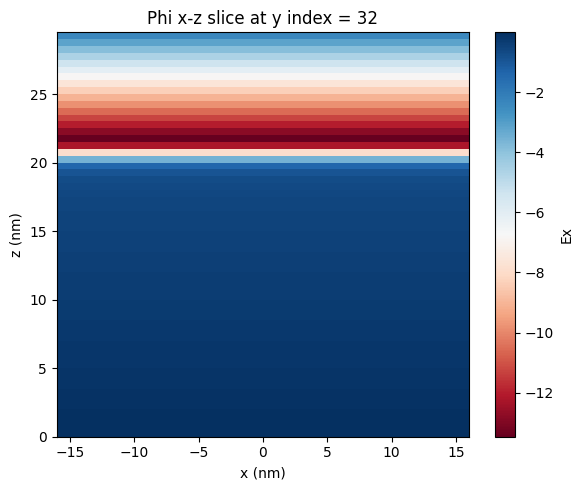

yt : [INFO     ] 2026-05-28 13:12:05,776 Parameters: current_time              = 3.4600000000000086e-11
yt : [INFO     ] 2026-05-28 13:12:05,776 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:05,777 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:05,777 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


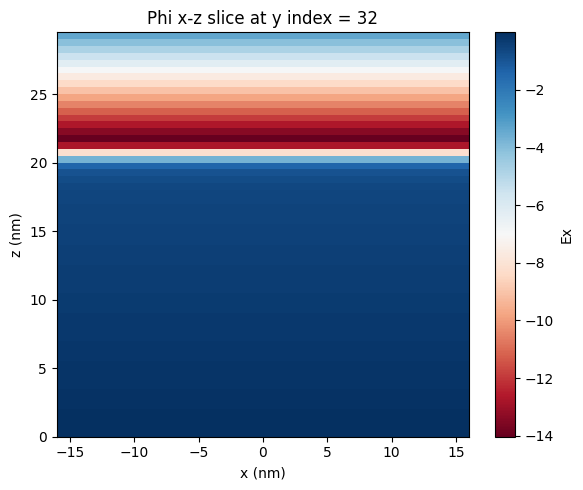

yt : [INFO     ] 2026-05-28 13:12:05,997 Parameters: current_time              = 3.6400000000000115e-11
yt : [INFO     ] 2026-05-28 13:12:05,998 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:05,999 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:05,999 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


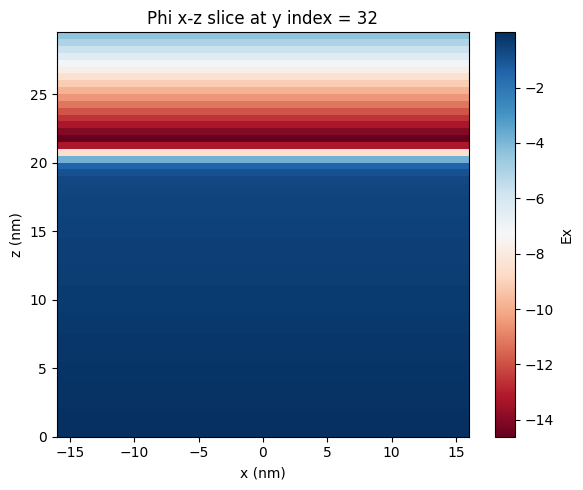

yt : [INFO     ] 2026-05-28 13:12:06,216 Parameters: current_time              = 3.8200000000000143e-11
yt : [INFO     ] 2026-05-28 13:12:06,217 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:06,217 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:06,218 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


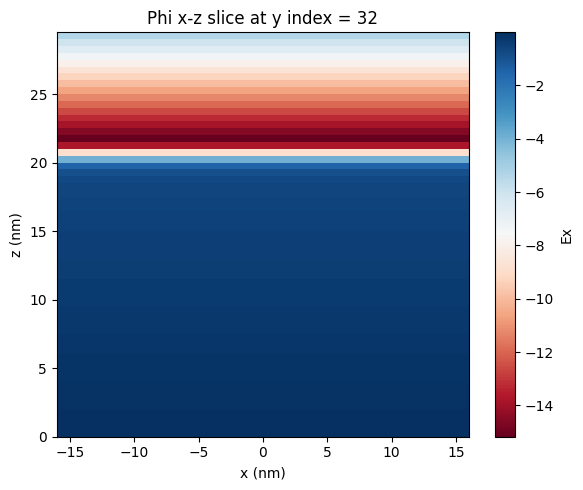

In [13]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-05-28 13:12:06,444 Parameters: current_time              = 4.8e-12
yt : [INFO     ] 2026-05-28 13:12:06,444 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:06,445 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:06,445 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


E_array shape = (64, 64, 59)


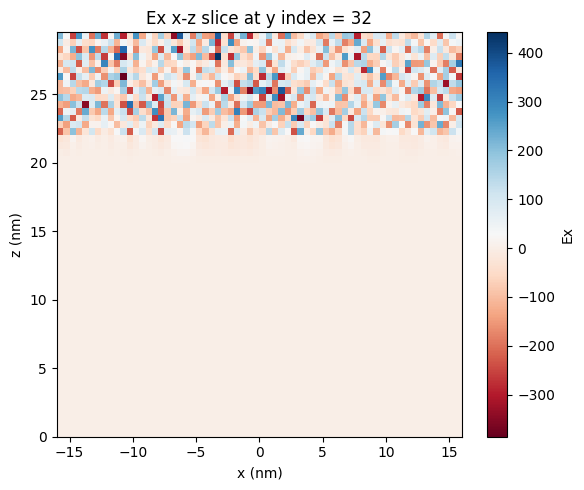

In [14]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[1] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-05-28 13:12:06,704 Parameters: current_time              = 4.8e-12
yt : [INFO     ] 2026-05-28 13:12:06,705 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:06,705 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:06,706 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Plotfiles to draw:
  plt00000024
  plt00000033
  plt00000042
  plt00000051
  plt00000059
  plt00000067
  plt00000075
  plt00000083
  plt00000091
  plt00000099
  plt00000107
  plt00000115
  plt00000123
  plt00000131
  plt00000139
  plt00000147
  plt00000155
  plt00000164
  plt00000173
  plt00000182
  plt00000191


yt : [INFO     ] 2026-05-28 13:12:06,964 Parameters: current_time              = 6.599999999999999e-12
yt : [INFO     ] 2026-05-28 13:12:06,964 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:06,965 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:06,965 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:07,078 Parameters: current_time              = 8.4e-12
yt : [INFO     ] 2026-05-28 13:12:07,078 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:07,079 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:07,079 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:07,191 Parameters: current_time              = 1.02e-11
yt : [INFO     ] 2026-05-28 13:12:07,192 Parameters: domain_dimensions         = [64 64 59]
yt

Saved figure: /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/Pz_FE_layer_stack.png


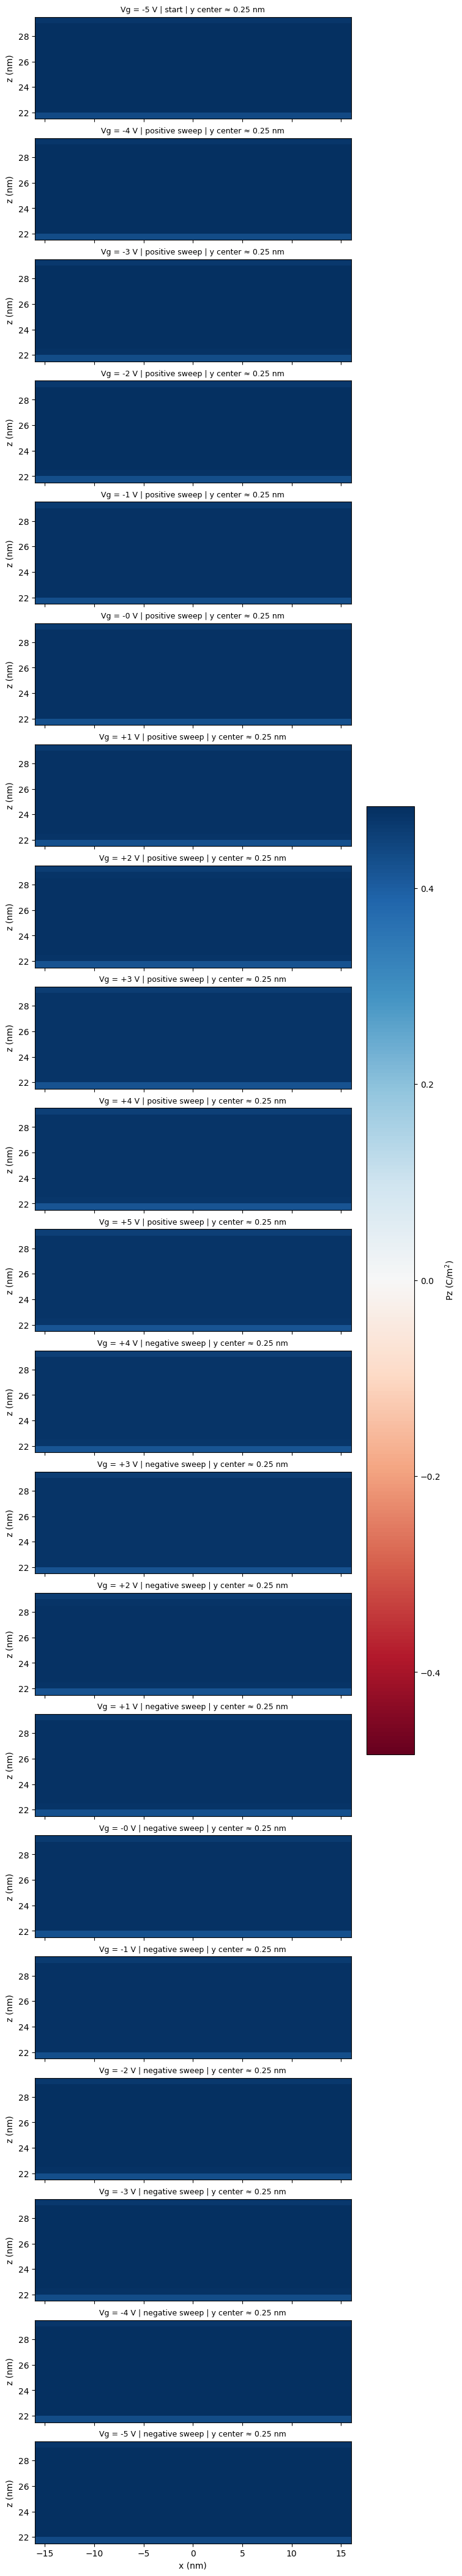

In [15]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")



USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = True

# 輸出圖片名稱
SAVE_FIG = True
OUT_FIG = PLOT_DIR/"Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid

    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

# figure size
n = len(records)
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)

if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.0f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")

cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## 3D Scatter plot (all voltage in same graph)

* trash

yt : [INFO     ] 2026-05-28 13:12:13,318 Parameters: current_time              = 4.8e-12
yt : [INFO     ] 2026-05-28 13:12:13,319 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:13,320 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:13,320 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:13,425 Parameters: current_time              = 6.599999999999999e-12
yt : [INFO     ] 2026-05-28 13:12:13,425 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:13,426 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:13,427 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Plotfiles to read:
  plt00000024
  plt00000033
  plt00000042
  plt00000051
  plt00000059
  plt00000067
  plt00000075
  plt00000083
  plt00000091
  plt00000099
  plt00000107
  plt00000115
  plt00000123
  plt00000131
  plt00000139
  plt00000147
  plt00000155
  plt00000164
  plt00000173
  plt00000182
  plt00000191


yt : [INFO     ] 2026-05-28 13:12:13,758 Parameters: current_time              = 8.4e-12
yt : [INFO     ] 2026-05-28 13:12:13,758 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:13,759 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:13,760 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:13,865 Parameters: current_time              = 1.02e-11
yt : [INFO     ] 2026-05-28 13:12:13,866 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:13,866 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:13,867 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:13,974 Parameters: current_time              = 1.1799999999999999e-11
yt : [INFO     ] 2026-05-28 13:12:13,974 Parameters: domain_dimensions         = [64 64 59]
y


Read records:
plt00000024  step=24  Vtop=-5.3508 V  Vround=-5  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000033  step=33  Vtop=-4.3638 V  Vround=-4  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000042  step=42  Vtop=-3.3767 V  Vround=-3  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000051  step=51  Vtop=-2.3896 V  Vround=-2  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000059  step=59  Vtop=-1.4024 V  Vround=-1  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000067  step=67  Vtop=-0.4153 V  Vround=-0  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000075  step=75  Vtop=+0.5719 V  Vround=+1  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000083  step=83  Vtop=+1.5592 V  Vround=+2  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000091  step=91  Vtop=+2.5465 V  Vround=+3  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000099  step=99  Vtop=+3.5338 V  Vround=+4  shape_fe=(64, 64, 16)  shape_plot=(32, 32, 8)
plt00000107  step=107  Vtop=+4.5212

/tmp/ipykernel_542292/2315896281.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.03, 0.94, 0.93])



Saved figure: /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/Pz_FE_3D_2x11_sweep.png


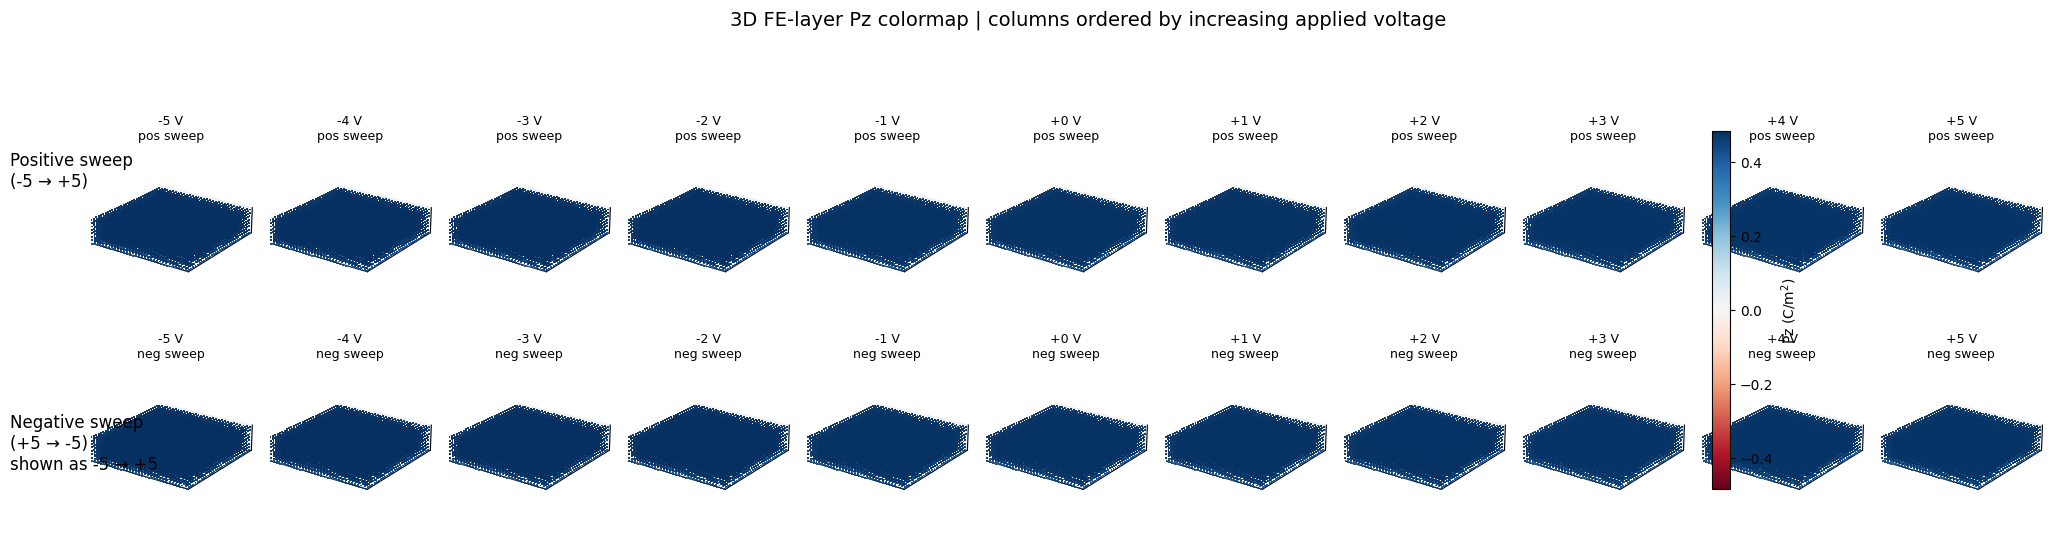

In [16]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 若 FE 只在部分 x/y 範圍，打開這裡
USE_FE_X_RANGE = False

USE_FE_Y_RANGE = False




# 用 top Phi 平均值四捨五入到整數電壓來分類
V_ROUND_DECIMALS = 0

# 3D 點太多會慢，STRIDE=2 表示 x/y/z 每 2 點取 1 點
# 若想更細可設 1；若很慢可設 3 或 4
STRIDE = 2

# 顏色是否以 0 對稱，畫 Pz 建議 True
SYMMETRIC_COLOR_SCALE = True

# 3D 視角
ELEV = 22
AZIM = -55

# 點大小
POINT_SIZE = 2

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 若你已經有 plot_names，就保留 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = False

SAVE_FIG = True
OUT_FIG = PLOT_DIR/"Pz_FE_3D_2x11_sweep.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot_3d(plotfile):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid

    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    # FE selection
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    # Apply selection
    P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

    x_fe = x_nm[x_sel]
    y_fe = y_nm[y_sel]
    z_fe = z_nm[z_sel]

    # Downsample for 3D plotting
    P_ds = P_fe[::STRIDE, ::STRIDE, ::STRIDE]
    x_ds = x_fe[::STRIDE]
    y_ds = y_fe[::STRIDE]
    z_ds = z_fe[::STRIDE]

    X, Y, Z = np.meshgrid(x_ds, y_ds, z_ds, indexing="ij")

    # Estimate top voltage from top cell Phi
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    return {
        "P": P_ds,
        "X": X,
        "Y": Y,
        "Z": Z,
        "x_range": (float(np.min(x_fe)), float(np.max(x_fe))),
        "y_range": (float(np.min(y_fe)), float(np.max(y_fe))),
        "z_range": (float(np.min(z_fe)), float(np.max(z_fe))),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape_full": P.shape,
        "shape_fe": P_fe.shape,
        "shape_plot": P_ds.shape,
    }


def classify_sweep(records):
    """
    根據 records 原本的時間順序，用 Vtop 的變化判斷正掃/負掃。
    第一個點歸到 positive，因為通常是正掃起點。
    turning point 會同時加入 positive 與 negative，讓上下排都有 +5。
    """
    pos = []
    neg = []

    V = np.array([r["Vtop_mean"] for r in records], dtype=float)

    if len(records) == 0:
        return pos, neg

    pos.append(records[0])

    for i in range(1, len(records)):
        dV = V[i] - V[i - 1]

        if dV > 1e-8:
            pos.append(records[i])
        elif dV < -1e-8:
            # 如果剛從正掃轉負掃，把上一個 turning point 也放進 neg
            if len(neg) == 0:
                neg.append(records[i - 1])
            neg.append(records[i])
        else:
            # 同電壓重複時，不確定歸類；先放到目前方向
            if len(neg) == 0:
                pos.append(records[i])
            else:
                neg.append(records[i])

    return pos, neg


def pick_record_by_voltage(records, target_v):
    """
    從一組 records 中挑最接近 target_v 的那筆。
    """
    if len(records) == 0:
        return None

    V = np.array([r["Vround"] for r in records], dtype=float)
    idx = int(np.argmin(np.abs(V - target_v)))

    if np.abs(V[idx] - target_v) > 0.25:
        return None

    return records[idx]


def draw_3d_fe(ax, rec, norm, cmap):
    P = rec["P"]
    X = rec["X"]
    Y = rec["Y"]
    Z = rec["Z"]

    ax.scatter(
        X.ravel(),
        Y.ravel(),
        Z.ravel(),
        c=P.ravel(),
        cmap=cmap,
        norm=norm,
        s=POINT_SIZE,
        marker="s",
        linewidths=0,
        alpha=0.95,
    )

    ax.set_xlim(rec["x_range"])
    ax.set_ylim(rec["y_range"])
    ax.set_zlim(rec["z_range"])

    ax.view_init(elev=ELEV, azim=AZIM)

    # 22 張小圖，不要塞太多刻度
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_box_aspect((
        rec["x_range"][1] - rec["x_range"][0],
        rec["y_range"][1] - rec["y_range"][0],
        rec["z_range"][1] - rec["z_range"][0],
    ))


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

print("Plotfiles to read:")
for n in plot_names_use:
    print(" ", n)

records = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot_3d(plotfile)

    Vround = np.round(info["Vtop_mean"], V_ROUND_DECIMALS)

    rec = {
        "name": name,
        "step": get_step_from_name(name),
        "Vround": float(Vround),
        **info,
    }

    records.append(rec)

print("\nRead records:")
for r in records:
    print(
        f"{r['name']}  step={r['step']}  "
        f"Vtop={r['Vtop_mean']:+.4f} V  Vround={r['Vround']:+.0f}  "
        f"shape_fe={r['shape_fe']}  shape_plot={r['shape_plot']}"
    )

# classify positive / negative sweep from time ordering
pos_records, neg_records = classify_sweep(records)

print("\nPositive sweep records:")
for r in pos_records:
    print(f"  V={r['Vround']:+.0f}  {r['name']}")

print("\nNegative sweep records:")
for r in neg_records:
    print(f"  V={r['Vround']:+.0f}  {r['name']}")

# Arrange columns left-to-right by increasing voltage: -5, -4, ..., 5
pos_grid = [pick_record_by_voltage(pos_records, v) for v in VOLTAGES]
neg_grid = [pick_record_by_voltage(neg_records, v) for v in VOLTAGES]

# shared color scale from all selected records
selected_records = [r for r in pos_grid + neg_grid if r is not None]
if len(selected_records) == 0:
    raise RuntimeError("No records selected. Check plot_names or voltage classification.")

all_p = np.concatenate([r["P"].ravel() for r in selected_records])

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_p))
    vmin = -vmax
else:
    vmin = np.nanmin(all_p)
    vmax = np.nanmax(all_p)

cmap = "RdBu"
norm = Normalize(vmin=vmin, vmax=vmax)

# 2 x 11 figure
fig = plt.figure(figsize=(22, 6.2))

axes = np.empty((2, len(VOLTAGES)), dtype=object)

for row in range(2):
    for col in range(len(VOLTAGES)):
        axes[row, col] = fig.add_subplot(
            2,
            len(VOLTAGES),
            row * len(VOLTAGES) + col + 1,
            projection="3d"
        )

for col, Vtarget in enumerate(VOLTAGES):
    rec = pos_grid[col]
    ax = axes[0, col]

    if rec is not None:
        draw_3d_fe(ax, rec, norm, cmap)
        ax.set_title(f"{Vtarget:+.0f} V\npos sweep", fontsize=9)
    else:
        ax.set_title(f"{Vtarget:+.0f} V\nmissing", fontsize=9)
        ax.axis("off")

for col, Vtarget in enumerate(VOLTAGES):
    rec = neg_grid[col]
    ax = axes[1, col]

    if rec is not None:
        draw_3d_fe(ax, rec, norm, cmap)
        ax.set_title(f"{Vtarget:+.0f} V\nneg sweep", fontsize=9)
    else:
        ax.set_title(f"{Vtarget:+.0f} V\nmissing", fontsize=9)
        ax.axis("off")

# row labels
fig.text(0.01, 0.72, "Positive sweep\n(-5 → +5)", va="center", ha="left", fontsize=12)
fig.text(0.01, 0.28, "Negative sweep\n(+5 → -5)\nshown as -5 → +5", va="center", ha="left", fontsize=12)

# shared colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    pad=0.01,
    location="right"
)
cbar.set_label(r"Pz (C/m$^2$)")

fig.suptitle(
    "3D FE-layer Pz colormap | columns ordered by increasing applied voltage",
    fontsize=14
)

plt.tight_layout(rect=[0.04, 0.03, 0.94, 0.93])

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"\nSaved figure: {OUT_FIG}")

plt.show()

## 3D Contour plot

* 畫出長方體三個面
* 選擇要畫的三個面C1,C2,C3
* 選擇視角

yt : [INFO     ] 2026-05-28 13:12:23,454 Parameters: current_time              = 2.14e-11
yt : [INFO     ] 2026-05-28 13:12:23,454 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:23,455 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:23,455 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]



Saved figure: /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/Pz_FE_3D_contour.png


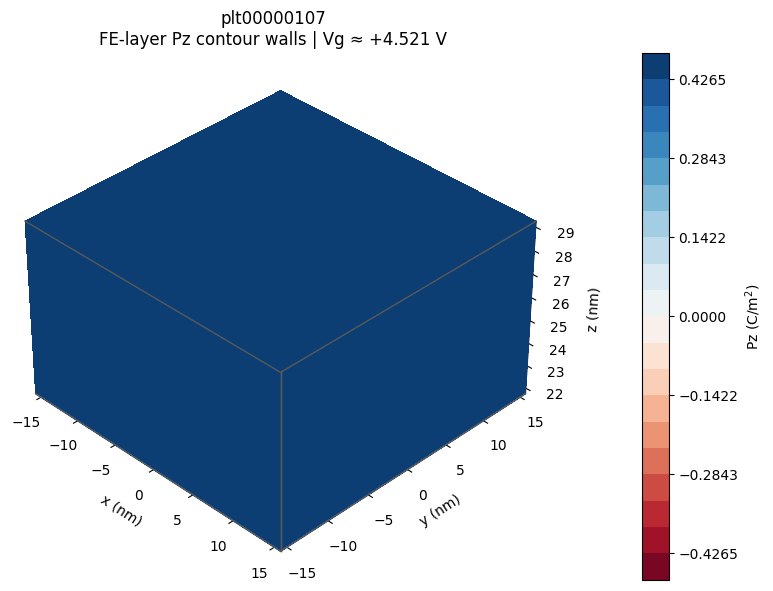

In [17]:
from pathlib import Path

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")
   # 改成你要畫的 plotfile

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 只想取部分 x/y 範圍
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False


# contour levels
N_LEVELS = 21

# 視角
ELEV = 35
AZIM = -45

# 色階是否對稱於 0
SYMMETRIC_COLOR_SCALE = True

SAVE_FIG= True
OUT_FIG = PLOT_DIR/"Pz_FE_3D_contour.png"

# ==========================
# Helper
# ==========================

def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


# ==========================
# Load data
# ==========================

plotfile = PLOT_DIR / PLOTFILE_NAME
ds = yt.load(str(plotfile))
g = ds.index.grids[0]

P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid

if PHI_FIELD in ds.field_list:
    Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
else:
    Phi = None

Nx, Ny, Nz = P.shape

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dx = (hi - lo) / np.array([Nx, Ny, Nz])

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9


# ==========================
# Select FE layer
# ==========================

z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

if USE_FE_X_RANGE:
    x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
else:
    x_sel = np.ones_like(x_nm, dtype=bool)

if USE_FE_Y_RANGE:
    y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
else:
    y_sel = np.ones_like(y_nm, dtype=bool)

P_fe = P[np.ix_(x_sel, y_sel, z_sel)]

x_fe = x_nm[x_sel]
y_fe = y_nm[y_sel]
z_fe = z_nm[z_sel]

Nx_fe, Ny_fe, Nz_fe = P_fe.shape

# 選三個切面：
# xy plane at top FE surface
k_top = Nz_fe - 1

# xz plane at y min side
#j_mid = Ny_fe // 2

# yz plane at x max side
i_right = Nx_fe - 1

P_xy = P_fe[:, :, k_top]      # shape (Nx, Ny)
P_xz = P_fe[:, 0, :]      # shape (Nx, Nz)
P_yz = P_fe[i_right, :, :]    # shape (Ny, Nz)

# 建立 2D coordinates
X_xy, Y_xy = np.meshgrid(x_fe, y_fe, indexing="ij")
X_xz, Z_xz = np.meshgrid(x_fe, z_fe, indexing="ij")
Y_yz, Z_yz = np.meshgrid(y_fe, z_fe, indexing="ij")


# ==========================
# Voltage label
# ==========================

if Phi is not None:
    top_phi = Phi[:, :, -1]
    Vtop_mean = float(np.mean(top_phi))
else:
    Vtop_mean = np.nan


# ==========================
# Color scale
# ==========================

if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(P_fe))
    vmin = -vmax
else:
    vmin = np.nanmin(P_fe)
    vmax = np.nanmax(P_fe)

levels = np.linspace(vmin, vmax, N_LEVELS)

kw = dict(
    levels=levels,
    vmin=vmin,
    vmax=vmax,
    cmap="RdBu",
)


# ==========================
# Plot 3D contour walls
# ==========================

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

xmin, xmax = x_fe.min(), x_fe.max()
ymin, ymax = y_fe.min(), y_fe.max()
zmin, zmax = z_fe.min(), z_fe.max()

# 1. xy plane, placed at z = zmax
# contourf expects arrays with same shape.
# X_xy/Y_xy/P_xy are (Nx, Ny)
C1 = ax.contourf(
    X_xy,
    Y_xy,
    P_xy,
    zdir="z",
    offset=zmax,
    **kw
)

# 2. xz plane, placed at y = ymin
# Here x-axis is X_xz, vertical is Z_xz, color is P_xz
C2 = ax.contourf(
    X_xz,
    P_xz,
    Z_xz,
    zdir="y",
    offset=ymin,
    **kw
)

# 3. yz plane, placed at x = xmax
# Here horizontal axis is Y_yz, vertical is Z_yz, color is P_yz
C3 = ax.contourf(
    P_yz,
    Y_yz,
    Z_yz,
    zdir="x",
    offset=xmax,
    **kw
)

# Set axis limits
ax.set(
    xlim=[xmin, xmax],
    ylim=[ymin, ymax],
    zlim=[zmin, zmax],
)

# Draw box edges
edges_kw = dict(color="0.35", linewidth=1.0, zorder=1000)

# 只畫可見的外框邊，不畫背後被內容遮住的線
visible_edges = [
    # bottom/front-ish edges
    ([xmin, xmax], [ymin, ymin], [zmin, zmin]),
    ([xmax, xmax], [ymin, ymax], [zmin, zmin]),
    ([xmax, xmax], [ymin, ymin], [zmin, zmax]),

    # top/front-ish edges
    ([xmin, xmax], [ymin, ymin], [zmax, zmax]),
    ([xmax, xmax], [ymin, ymax], [zmax, zmax]),
    ([xmax, xmax], [ymin, ymin], [zmin, zmax]),
]

for xs, ys, zs in visible_edges:
    ax.plot(xs, ys, zs, **edges_kw)
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_zlabel("z (nm)")

ax.view_init(ELEV, AZIM)
Z_VISUAL_SCALE = 2.5
ax.set_box_aspect((
    xmax - xmin,
    ymax - ymin,
    Z_VISUAL_SCALE * (zmax - zmin)
))

ax.set_title(
    f"{PLOTFILE_NAME}\n"
    f"FE-layer Pz contour walls | Vg ≈ {Vtop_mean:+.3f} V"
)

cbar = fig.colorbar(C3, ax=ax, fraction=0.035, pad=0.12)
cbar.set_label(r"Pz (C/m$^2$)")

plt.tight_layout()

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=300)
    print(f"\nSaved figure: {OUT_FIG}")

plt.show()

## PV

In [18]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = PLOT_DIR/"MFIS_PV_curve.csv"
OUT_FIG = PLOT_DIR/"MFIS_PV_curve.png"


# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }


# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-05-28 13:12:24,072 Parameters: current_time              = 4.8e-12
yt : [INFO     ] 2026-05-28 13:12:24,073 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:24,073 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:24,073 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Finding plotfiles in /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt...
['plt00000024', 'plt00000033', 'plt00000042', 'plt00000051', 'plt00000059', 'plt00000067', 'plt00000075', 'plt00000083', 'plt00000091', 'plt00000099', 'plt00000107', 'plt00000115', 'plt00000123', 'plt00000131', 'plt00000139', 'plt00000147', 'plt00000155', 'plt00000164', 'plt00000173', 'plt00000182', 'plt00000191']


yt : [INFO     ] 2026-05-28 13:12:24,190 Parameters: current_time              = 6.599999999999999e-12
yt : [INFO     ] 2026-05-28 13:12:24,190 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:24,191 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:24,192 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000024
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000024 | step=24 | Vg=-5.3508 V | <Pz>_FE=+4.798746e-01


yt : [INFO     ] 2026-05-28 13:12:24,301 Parameters: current_time              = 8.4e-12
yt : [INFO     ] 2026-05-28 13:12:24,301 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:24,302 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:24,303 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


...

Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000139
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000139 | step=139 | Vg=+0.5719 V | <Pz>_FE=+4.733916e-01
Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000147
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000147 | step=147 | Vg=-0.4153 V | <Pz>_FE=+4.744966e-01


yt : [INFO     ] 2026-05-28 13:12:26,175 Parameters: current_time              = 3.280000000000006e-11
yt : [INFO     ] 2026-05-28 13:12:26,176 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:26,176 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:26,177 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:26,283 Parameters: current_time              = 3.4600000000000086e-11
yt : [INFO     ] 2026-05-28 13:12:26,284 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:26,284 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:26,285 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000155
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000155 | step=155 | Vg=-1.4024 V | <Pz>_FE=+4.755915e-01
Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000164
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000164 | step=164 | Vg=-2.3896 V | <Pz>_FE=+4.766766e-01


yt : [INFO     ] 2026-05-28 13:12:26,399 Parameters: current_time              = 3.6400000000000115e-11
yt : [INFO     ] 2026-05-28 13:12:26,400 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:26,401 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:26,401 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-05-28 13:12:26,532 Parameters: current_time              = 3.8200000000000143e-11
yt : [INFO     ] 2026-05-28 13:12:26,532 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-05-28 13:12:26,533 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-28 13:12:26,534 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000173
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000173 | step=173 | Vg=-3.3767 V | <Pz>_FE=+4.777520e-01
Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000182
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000182 | step=182 | Vg=-4.3638 V | <Pz>_FE=+4.788179e-01
Read Pz with shape (64, 64, 59) from /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/plt00000191
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.950e-08] m
plt00000191 | step=191 | Vg=-5.3508 V | <Pz>_FE=+4.798746e-01
Saved CSV: /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/MFIS_PV_curve.csv


Saved figure: /home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_3_plt/MFIS_PV_curve.png


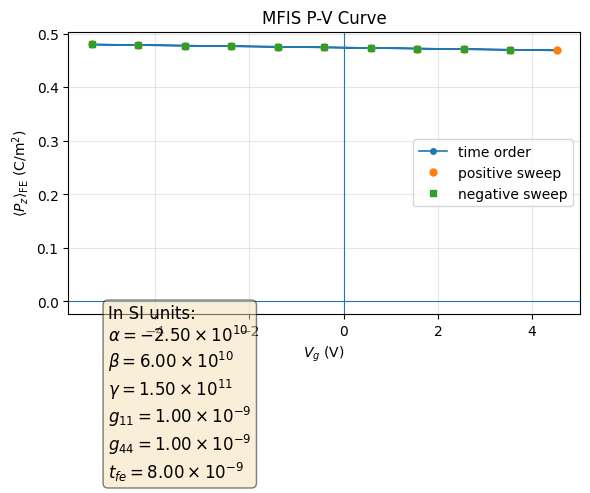

In [19]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(-5, -0.005, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, P, "-o", markersize=4, linewidth=1.2, label="time order")

# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], P[pos], "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], P[neg], "s", markersize=5, label="negative sweep")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (C/m$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()